## Investigating the Invariant Mass vs Missing Mass Mismatch Issue

In [1]:
import pandas as pd
import numpy as np

from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer
from pathlib import Path
import vector

In [2]:
nuclear_map = NuclearDataMap()
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m

target_material_path = Path("/Users/pranjalsingh/Desktop/research_space_engine/e20020_engine/target_10B.json")

ejectile_z = 1
ejectile_a = 1

# The incoming nucleus (the beam)
projectile_z = 5
projectile_a = 10


# The target nucleus
target_z = 1
target_a = 2

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a
print(residual_a,residual_z)

if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")

11 5


In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
# fusion = nuclear_map.get_data(fusion_z, fusion_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 95 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel #- ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]

# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic #- ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit #- ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic #- attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")

Reaction: 2H(10B, 1H)11B
Target material: (Gas)2H2
Accelerator Beam energy: 95 MeV
Beam energy after IC (2 windows + gas): 95 MeV
Beam energy range in AT-TPC: 95-75.58050296324579 MeV


## df from engine

In [4]:
event = 5

In [5]:
df = pd.read_parquet("/Users/pranjalsingh/Desktop/research_space_engine/e20020_engine/my_sim/output_16O_invariant/kinematics/b11_18_4_li7_4_6_0_6.parquet")
df

,event,Z,A,isotope,energy,px,py,pz,vertex_x,vertex_y,vertex_z
0,0,1,2,2H,1875.612931,0.000000,0.000000,0.000000,0.009237,0.006936,0.864722
1,0,5,10,10B,9402.874388,0.000000,0.000000,1211.993340,0.009237,0.006936,0.864722
2,0,1,1,1H,952.841018,71.575477,-21.399077,148.224655,0.009237,0.006936,0.864722
3,0,5,11,11B,10325.646301,-71.575477,21.399077,1063.768684,0.009237,0.006936,0.864722
4,0,2,4,4He,3741.355855,93.871680,51.880208,304.767930,0.009237,0.006936,0.864722
...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,5,11,11B,10339.531910,74.738884,-71.421451,1186.206250,0.001199,0.000090,0.228087
79996,9999,2,4,4He,3750.489673,75.319304,-154.584031,378.479695,0.001199,0.000090,0.228087
79997,9999,3,7,7Li,6589.042237,-0.580420,83.162580,807.726555,0.001199,0.000090,0.228087
79998,9999,1,3,3H,2828.096638,7.117166,-50.995059,324.717672,0.001199,0.000090,0.228087


In [6]:
filtered_df = df[(df["event"] == event) & (df["Z"]== 1) ]

unique_events = np.unique(df["event"])

## df from Solver (decay and target)

In [7]:
filtered_df

,event,Z,A,isotope,energy,px,py,pz,vertex_x,vertex_y,vertex_z
40,5,1,2,2H,1875.612931,0.000000,0.000000,0.000000,0.002133,0.008591,0.675393
42,5,1,1,1H,938.514385,-21.223879,1.564549,-1.364313,0.002133,0.008591,0.675393
46,5,1,3,3H,2826.399041,-49.415587,20.926497,309.214888,0.002133,0.008591,0.675393


## Total energy

### What the sum should be (engine)

In [8]:
# total_inv_engine = filtered_df['energy'].tail(4).sum()
# print(total_inv_engine)

### What is sum is (spyral)

In [9]:
# total_inv_spyral = filtered_df_decay['energy'].tail(4).sum()
# print(total_inv_spyral)

## Invariant energy

### engine

In [10]:
# px_eng_tot = filtered_df["px"].tail(4).sum()
# py_eng_tot = filtered_df["py"].tail(4).sum()
# pz_eng_tot = filtered_df["pz"].tail(4).sum()

# p_eng_tot = np.sqrt(
#             px_eng_tot**2
#             + py_eng_tot**2
#             + pz_eng_tot**2
#         )

# inv_mass_eng = np.sqrt(
#             total_inv_engine**2 - p_eng_tot**2
#         )

# inv_energy_eng = inv_mass_eng - projectile.mass #projectile mass 16O

# print(f"Engine 16O excitation energy: {inv_energy_eng} MeV")


## Missing mass

### engine

In [11]:
target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
})

# vertices_eng = filtered_df[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy() 
# print(f"Verticies: {vertices_eng}")
distance_eng = filtered_df["vertex_z"].to_numpy()

projectile_ke_eng = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_eng))

projectile_vector_eng = vector.array({
        "px": np.zeros(len(projectile_ke_eng)),
        "py": np.zeros(len(projectile_ke_eng)),
        "pz": np.sqrt(projectile_ke_eng * (projectile_ke_eng + 2.0 * projectile.mass)),
        "E": projectile_ke_eng + projectile.mass
    })


ejectile_vector_eng = vector.array({
    "px": filtered_df["px"].to_numpy(),
    "py": filtered_df["py"].to_numpy(),
    "pz": filtered_df["pz"].to_numpy(),
    "E": filtered_df["energy"].to_numpy()
})
residual_vector = (target_vector + projectile_vector_eng - ejectile_vector_eng)
ex_eng = residual_vector.mass - residual.mass
print(f"Engine 16O excitation energy (missing): {ex_eng[1]} MeV")


Engine 16O excitation energy (missing): 16.313150340716675 MeV


In [12]:
missing_mass_eng = []

for event_num in unique_events:
    filtered_df = df[(df["event"] == event_num) & (df["Z"]== 1)]
    target_vector = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [0.0],
    "E": [target.mass]
    })

    vertices_eng = filtered_df[['vertex_x', 'vertex_y', 'vertex_z']].to_numpy() 
    # print(f"Verticies: {vertices_eng}")
    distance_eng = np.linalg.norm(vertices_eng,axis=1)

    projectile_ke_eng = (proj_energy_start - target_material.get_energy_loss(projectile,proj_energy_start,distance_eng))

    projectile_vector_eng = vector.array({
            "px": np.zeros(len(projectile_ke_eng)),
            "py": np.zeros(len(projectile_ke_eng)),
            "pz": np.sqrt(projectile_ke_eng * (projectile_ke_eng + 2.0 * projectile.mass)),
            "E": projectile_ke_eng + projectile.mass
        })


    ejectile_vector_eng = vector.array({
        "px": filtered_df["px"].to_numpy(),
        "py": filtered_df["py"].to_numpy(),
        "pz": filtered_df["pz"].to_numpy(),
        "E": filtered_df["energy"].to_numpy()
    })
    residual_vector = (target_vector + projectile_vector_eng - ejectile_vector_eng)
    ex_eng = residual_vector.mass - residual.mass
    missing_mass_eng.append(ex_eng[1])

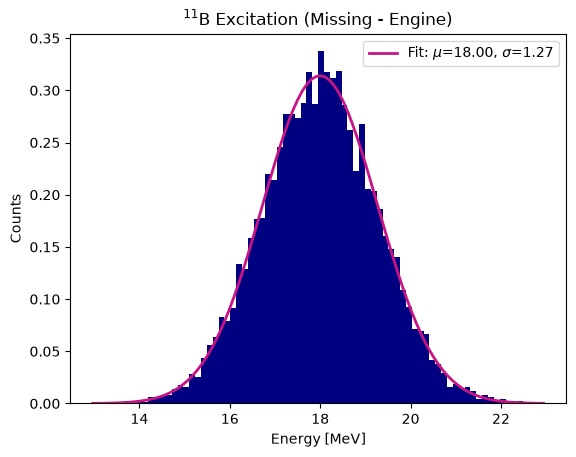

In [13]:
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, ax = plt.subplots()
counts, bins, patches =  ax.hist(missing_mass_eng, bins=70, color='navy',density=True)

mu, sigma = norm.fit(missing_mass_eng)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, sigma)

ax.plot(x, p, color='mediumvioletred', linewidth=2, label=f'Fit: $\mu$={mu:.2f}, $\sigma$={sigma:.2f}')
ax.legend()

plt.title(r"$^{11}$B Excitation (Missing - Engine)")
plt.xlabel("Energy [MeV]")
plt.ylabel("Counts")

plt.show()